In [483]:
# Importing the necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [484]:
# Loading the dataset
cars = pd.read_csv('second_hand_cars.csv')

In [485]:
cars.head(20)

,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,84-436-5584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels"
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,92-708-1763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels"
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,76-154-5485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System"
5,Volkswagen,Cruze,LE,Petrol,New,2021,Second,21-711-8793,28516,209930,Automatic,Gold,Major Service at 63857 km,No Current Insurance,Available,"Sunroof, Music System, Leather Seats"
6,Maruti Suzuki,Camry,NaN,CNG,Used,2017,Third,92-504-4180,70676,550187,Automatic,Red,Full Service History,Valid Until [date],Not Available,GPS
7,Toyota,F-150,NaN,CNG,New,2021,Second,78-995-2467,197377,344563,Automatic,Black,No Service Record,Valid Until [date],Not Available,"GPS, Leather Seats"
8,Volkswagen,Kwid,ZXI,Petrol,New,2022,Third,87-719-2138,155320,596554,Manual,Grey,Full Service History,No Current Insurance,Available,"GPS, Music System, Sunroof, Leather Seats"
9,Ford,Swift,GT,Petrol,Used,2018,Second,41-421-7619,16544,387560,Manual,White,Full Service History,Valid Until [date],Not Available,"Music System, Leather Seats, Alloy Wheels"


In [486]:
cars.shape

(2500, 16)

In [487]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Company Name              2500 non-null   str  
 1   Car Name                  2500 non-null   str  
 2   Variant                   2238 non-null   str  
 3   Fuel Type                 2500 non-null   str  
 4   Tyre Condition            2500 non-null   str  
 5   Make Year                 2500 non-null   int64
 6   Owner Type                2500 non-null   str  
 7   Registration Number       2500 non-null   str  
 8   Mileage                   2500 non-null   int64
 9   Price                     2500 non-null   int64
 10  Transmission Type         2500 non-null   str  
 11  Body Color                2500 non-null   str  
 12  Service Record            2500 non-null   str  
 13  Insurance                 2500 non-null   str  
 14  Registration Certificate  2500 non-null   str  
 15

In [488]:
cars.isnull().sum()

Company Name                  0
Car Name                      0
Variant                     262
Fuel Type                     0
Tyre Condition                0
Make Year                     0
Owner Type                    0
Registration Number           0
Mileage                       0
Price                         0
Transmission Type             0
Body Color                    0
Service Record                0
Insurance                     0
Registration Certificate      0
Accessories                 482
dtype: int64

In [489]:
# Checking for duplicates
cars.duplicated().sum()

np.int64(0)

In [490]:
# Investigating missing values in Variant and Accessories columns
(cars[['Variant', 'Accessories']].isnull().mean() * 100).round(2)

Variant        10.48
Accessories    19.28
dtype: float64

In [491]:
# Creating a missingness indicator to compare missing vs non missing records
cars['Variant_missing'] = cars['Variant'].isnull()
cars['Accessories_missing'] = cars['Accessories'].isnull()

In [492]:
# Checking the counts
cars['Variant_missing'].value_counts()

Variant_missing
False    2238
True      262
Name: count, dtype: int64

In [493]:
cars['Accessories_missing'].value_counts()

Accessories_missing
False    2018
True      482
Name: count, dtype: int64

**Comparing missingness with categorical variables**

In [494]:
# Variant
pd.crosstab(cars['Fuel Type'], cars['Variant_missing'])

Variant_missing,False,True
Fuel Type,,
CNG,749,91
Diesel,756,77
Petrol,733,94


In [495]:
pd.crosstab(cars['Company Name'], cars['Variant_missing'])

Variant_missing,False,True
Company Name,,
Chevrolet,221,28
Ford,217,32
Honda,237,20
Hyundai,206,16
Kia,232,34
Maruti Suzuki,216,30
Nissan,246,24
Renault,225,18
Toyota,221,29


In [496]:
pd.crosstab(cars['Transmission Type'], cars['Variant_missing'])

Variant_missing,False,True
Transmission Type,,
Automatic,744,96
Automatic (Tiptronic),734,91
Manual,760,75


In [497]:
cars.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Company Name              2500 non-null   str  
 1   Car Name                  2500 non-null   str  
 2   Variant                   2238 non-null   str  
 3   Fuel Type                 2500 non-null   str  
 4   Tyre Condition            2500 non-null   str  
 5   Make Year                 2500 non-null   int64
 6   Owner Type                2500 non-null   str  
 7   Registration Number       2500 non-null   str  
 8   Mileage                   2500 non-null   int64
 9   Price                     2500 non-null   int64
 10  Transmission Type         2500 non-null   str  
 11  Body Color                2500 non-null   str  
 12  Service Record            2500 non-null   str  
 13  Insurance                 2500 non-null   str  
 14  Registration Certificate  2500 non-null   str  
 15

In [498]:
# Accessories
pd.crosstab(cars['Company Name'], cars['Accessories_missing'])

Accessories_missing,False,True
Company Name,,
Chevrolet,180,69
Ford,194,55
Honda,219,38
Hyundai,174,48
Kia,219,47
Maruti Suzuki,204,42
Nissan,224,46
Renault,192,51
Toyota,206,44


In [499]:
pd.crosstab(cars['Fuel Type'], cars['Accessories_missing'])

Accessories_missing,False,True
Fuel Type,,
CNG,693,147
Diesel,664,169
Petrol,661,166


In [500]:
pd.crosstab(cars['Transmission Type'], cars['Accessories_missing'])

Accessories_missing,False,True
Transmission Type,,
Automatic,680,160
Automatic (Tiptronic),669,156
Manual,669,166


**Comparing missingness in numercial variables**

In [501]:
# Variant 
cars.groupby('Variant_missing')['Mileage'].describe()

,count,mean,std,min,25%,50%,75%,max
Variant_missing,,,,,,,,
False,2238.0,104463.503128,55395.691378,10010.0,56156.25,103465.5,151166.75,199755.0
True,262.0,107462.442748,56836.716184,11586.0,57715.75,109430.0,157937.50,199145.0


In [502]:
cars.groupby('Variant_missing')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Variant_missing,,,,,,,,
False,2238.0,606598.824397,229611.922968,200176.0,409097.5,608831.5,801965.25,999826.0
True,262.0,621122.423664,243113.396402,200539.0,398866.5,647848.5,841460.75,998718.0


In [503]:
cars.groupby('Variant_missing')['Make Year'].describe()

,count,mean,std,min,25%,50%,75%,max
Variant_missing,,,,,,,,
False,2238.0,2019.543789,2.891358,2015.0,2017.0,2020.0,2022.0,2024.0
True,262.0,2019.332061,2.916534,2015.0,2017.0,2019.0,2022.0,2024.0


In [504]:
# Accessories
cars.groupby('Accessories_missing')['Mileage'].describe()

,count,mean,std,min,25%,50%,75%,max
Accessories_missing,,,,,,,,
False,2018.0,105328.506442,55122.116478,10010.0,57443.75,105306.5,151961.50,199755.0
True,482.0,102472.103734,57280.114304,10080.0,50672.75,100560.0,153654.75,199355.0


In [505]:
cars.groupby('Accessories_missing')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Accessories_missing,,,,,,,,
False,2018.0,610994.554509,230212.390160,200176.0,412996.5,615751.5,803979.5,999826.0
True,482.0,596089.695021,234414.662715,201941.0,386285.5,593615.5,809738.0,997921.0


In [506]:
cars.groupby('Accessories_missing')['Make Year'].describe()

,count,mean,std,min,25%,50%,75%,max
Accessories_missing,,,,,,,,
False,2018.0,2019.453419,2.886390,2015.0,2017.0,2019.0,2022.0,2024.0
True,482.0,2019.807054,2.912107,2015.0,2017.0,2020.0,2022.0,2024.0


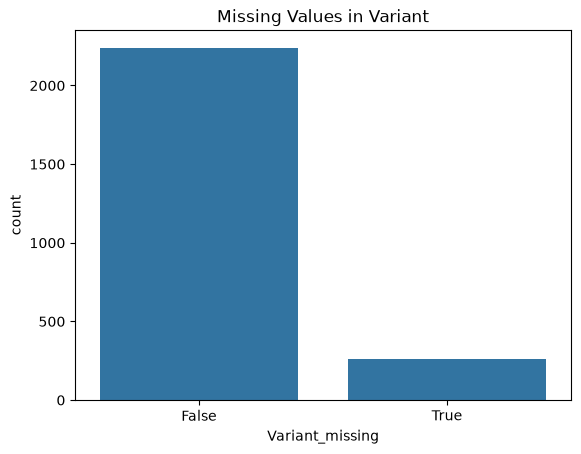

In [507]:
sns.countplot(x='Variant_missing', data=cars)
plt.title('Missing Values in Variant')
plt.show()

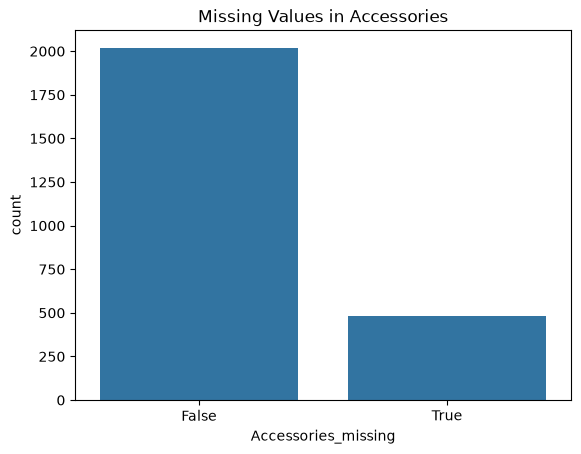

In [508]:
sns.countplot(x='Accessories_missing', data=cars)
plt.title('Missing Values in Accessories')
plt.show()

In [509]:
# Looking at the actual rows
cars[cars['Variant'].isnull()].head(10)

,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories,Variant_missing,Accessories_missing
6,Maruti Suzuki,Camry,NaN,CNG,Used,2017,Third,92-504-4180,70676,550187,Automatic,Red,Full Service History,Valid Until [date],Not Available,GPS,True,False
7,Toyota,F-150,NaN,CNG,New,2021,Second,78-995-2467,197377,344563,Automatic,Black,No Service Record,Valid Until [date],Not Available,"GPS, Leather Seats",True,False
10,Chevrolet,Sunny,NaN,CNG,Used,2019,Third,74-685-5799,56900,398364,Automatic,Blue,Full Service History,Valid Until [date],Available,"Leather Seats, Music System, Alloy Wheels, GPS",True,False
13,Chevrolet,Camry,NaN,Petrol,New,2019,Third,17-472-2864,91642,398425,Manual,Silver,Major Service at 107494 km,Valid Until [date],Not Available,"Sunroof, GPS",True,False
22,Kia,Accord,NaN,Diesel,Used,2019,Third,54-547-5118,181920,232657,Automatic,White,Major Service at 146566 km,No Current Insurance,Not Available,"Leather Seats, GPS, Alloy Wheels, Sunroof",True,False
27,Ford,Accord,NaN,Petrol,New,2024,Second,87-231-6139,176050,649268,Automatic (Tiptronic),Silver,Major Service at 127053 km,Valid Until [date],Not Available,NaN,True,True
31,Ford,Polo,NaN,Diesel,Needs Replacement,2019,Second,59-837-2061,124211,742015,Automatic (Tiptronic),Red,Full Service History,No Current Insurance,Not Available,"Music System, Alloy Wheels, Sunroof",True,False
37,Volkswagen,Elantra,NaN,Petrol,Needs Replacement,2020,Second,86-865-5627,38775,386004,Automatic,Grey,Full Service History,Valid Until [date],Available,NaN,True,True
49,Renault,Polo,NaN,CNG,Used,2023,Third,30-668-4549,153769,646429,Automatic,Maroon,Full Service History,No Current Insurance,Available,Leather Seats,True,False
51,Kia,Sunny,NaN,Diesel,Used,2017,First,86-197-7043,198556,716891,Automatic,Blue,No Service Record,No Current Insurance,Not Available,"Sunroof, Music System, Alloy Wheels, GPS",True,False


In [510]:
cars[cars['Accessories'].isnull()].head(10)

,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories,Variant_missing,Accessories_missing
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN,False,True
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN,False,True
27,Ford,Accord,NaN,Petrol,New,2024,Second,87-231-6139,176050,649268,Automatic (Tiptronic),Silver,Major Service at 127053 km,Valid Until [date],Not Available,NaN,True,True
30,Volkswagen,Sunny,XL,CNG,New,2018,Second,88-432-1473,52809,565267,Manual,Gold,No Service Record,Valid Until [date],Available,NaN,False,True
37,Volkswagen,Elantra,NaN,Petrol,Needs Replacement,2020,Second,86-865-5627,38775,386004,Automatic,Grey,Full Service History,Valid Until [date],Available,NaN,True,True
38,Hyundai,Sunny,EX,Petrol,New,2019,Second,69-150-5598,46025,527376,Manual,Grey,No Service Record,No Current Insurance,Not Available,NaN,False,True
39,Maruti Suzuki,F-150,Highline,CNG,New,2020,First,96-533-2831,13636,918001,Manual,Red,No Service Record,Valid Until [date],Available,NaN,False,True
54,Nissan,Elantra,Highline,Diesel,Needs Replacement,2020,First,63-285-3411,14052,333362,Automatic (Tiptronic),Gold,Major Service at 144984 km,No Current Insurance,Available,NaN,False,True
55,Chevrolet,Polo,ZXI,CNG,Used,2022,Third,86-447-4499,189689,599525,Automatic (Tiptronic),Blue,Full Service History,No Current Insurance,Not Available,NaN,False,True
64,Hyundai,Elantra,SL,CNG,Used,2015,Second,88-157-6816,167648,313157,Manual,White,Major Service at 126629 km,Valid Until [date],Not Available,NaN,False,True


Missingness was investigated by examining the distribution across categorical and numerical variables in relation to Variant and Accessories columns. Investigation found that missingness was found across multiple features indicating no obvious concentration within specific categories. Therefore, the missing values were considered likely to result from incomplete recording rather than systematic bias.

We shall impute them using placeholder categories, i.e: 'Unknown' for Variant and 'None' for Accessories.

In [511]:
cars['Variant'] = cars['Variant'].fillna('Unknown')
cars['Accessories'] = cars['Accessories'].fillna('None')

In [512]:
cars.isnull().sum()

Company Name                0
Car Name                    0
Variant                     0
Fuel Type                   0
Tyre Condition              0
Make Year                   0
Owner Type                  0
Registration Number         0
Mileage                     0
Price                       0
Transmission Type           0
Body Color                  0
Service Record              0
Insurance                   0
Registration Certificate    0
Accessories                 0
Variant_missing             0
Accessories_missing         0
dtype: int64

In [513]:
cars.drop(columns=['Variant_missing', 'Accessories_missing'], inplace=True)

In [514]:
cars.columns

Index(['Company Name', 'Car Name', 'Variant', 'Fuel Type', 'Tyre Condition',
       'Make Year', 'Owner Type', 'Registration Number', 'Mileage', 'Price',
       'Transmission Type', 'Body Color', 'Service Record', 'Insurance',
       'Registration Certificate', 'Accessories'],
      dtype='str')

**4. Feature Engineering**

4.1 Creating New Features

In [515]:
# Calculating the car age using the year of manufacture
current_year = 2026

cars['Car Age'] = current_year - cars['Make Year']

In [516]:
# Confirming the new feature has been created
cars[['Make Year', 'Car Age']].head()

,Make Year,Car Age
0,2018,8
1,2020,6
2,2022,4
3,2024,2
4,2018,8


In [517]:
# Creating Price per mile feature as well
cars['Price per Mile'] = cars['Price'] / cars['Mileage']

In [518]:
cars['Service Record'].unique()

<StringArray>
[ 'Major Service at 50418 km', 'Major Service at 131313 km',
          'No Service Record',  'Major Service at 98115 km',
 'Major Service at 135665 km',  'Major Service at 63857 km',
       'Full Service History', 'Major Service at 107494 km',
 'Major Service at 133362 km', 'Major Service at 146566 km',
 ...
 'Major Service at 112307 km', 'Major Service at 149462 km',
 'Major Service at 140004 km',  'Major Service at 76189 km',
 'Major Service at 107110 km',  'Major Service at 61131 km',
  'Major Service at 95228 km',  'Major Service at 55234 km',
 'Major Service at 105579 km', 'Major Service at 112605 km']
Length: 849, dtype: str

In [519]:
cars['Serviced km'] = (
    cars['Service Record']
        .str.extract(r'(\d+)\s*km')
        .astype(float)
        .fillna(0)
)

cars['Has Full Service History'] = (
    cars['Service Record'] == 'Full Service History'
).astype(int)

cars['Has Service Record'] = (
    cars['Service Record'] != 'No Service Record'
).astype(int)

In [520]:
cars['Accessories'].head(10)

0          Music System, Sunroof, Alloy Wheels
1                                         None
2                                         None
3                   Music System, Alloy Wheels
4                            GPS, Music System
5         Sunroof, Music System, Leather Seats
6                                          GPS
7                           GPS, Leather Seats
8    GPS, Music System, Sunroof, Leather Seats
9    Music System, Leather Seats, Alloy Wheels
Name: Accessories, dtype: str

In [521]:
# Count how many accessories each car has (comma-separated list)
cars['Number of Accessories'] = cars['Accessories'].apply(
    lambda x: 0 if pd.isna (x) or x == 'None' else len(x.split(','))
)

cars[['Car Age', 'Price per Mile', 'Serviced km', 'Has Full Service History',
      'Insurance', 'Registration Certificate', 'Number of Accessories']].head()

,Car Age,Price per Mile,Serviced km,Has Full Service History,Insurance,Registration Certificate,Number of Accessories
0,8,14.377571,50418.0,0,No Current Insurance,Not Available,3
1,6,11.634364,131313.0,0,No Current Insurance,Available,0
2,4,6.672219,0.0,0,No Current Insurance,Available,0
3,2,6.865880,98115.0,0,Valid Until [date],Available,2
4,8,8.304536,135665.0,0,No Current Insurance,Not Available,2


Dropping Identifier columns since it carries no predictive signal.

In [522]:
cars = cars.drop(columns=['Registration Number', 'Car Name', 'Service Record', 'Accessories', 'Make Year'])

Splitting the data before encoding to avoid data leakage

In [523]:
# Separating the features and target
X = cars.drop(columns=['Price', 'Price per Mile'])
y = cars['Price']

In [524]:
# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [525]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(2000, 15)
(500, 15)
(2000,)
(500,)


4.2 Encoding Categorical Features

In [526]:
X_train.dtypes

Company Name                    str
Variant                         str
Fuel Type                       str
Tyre Condition                  str
Owner Type                      str
Mileage                       int64
Transmission Type               str
Body Color                      str
Insurance                       str
Registration Certificate        str
Car Age                       int64
Serviced km                 float64
Has Full Service History      int64
Has Service Record            int64
Number of Accessories         int64
dtype: object

In [527]:
# Checking uniqueness of our features to determine encoding technique
categorical_cols = X_train.select_dtypes(include='str').columns

X_train[categorical_cols].nunique()

Company Name                10
Variant                     10
Fuel Type                    3
Tyre Condition               3
Owner Type                   3
Transmission Type            3
Body Color                   8
Insurance                    2
Registration Certificate     2
dtype: int64

*One-hot Encoding*

In [528]:
# Training Set
X_train = pd.get_dummies(
    X_train,
    columns=[
        'Company Name',
        'Variant',
        'Fuel Type',
        'Tyre Condition',
        'Owner Type',
        'Transmission Type',
        'Body Color', 
    ],
    drop_first=True,
    dtype=int
)

In [529]:
# Testing Set
X_test = pd.get_dummies(
    X_test,
    columns=[
        'Company Name',
        'Variant',
        'Fuel Type',
        'Tyre Condition',
        'Owner Type',
        'Transmission Type',
        'Body Color', 
    ],
    drop_first=True,
    dtype=int
)

In [530]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

*Binary Encoding*

In [531]:
X_train['Registration Certificate'].value_counts()

Registration Certificate
Available        1014
Not Available     986
Name: count, dtype: int64

In [532]:
# Training Set
X_train['Registration Certificate'] = X_train['Registration Certificate'].map({
    'Available': 1,
    'Not Available': 0
})

In [533]:
# Testing Set
X_test['Registration Certificate'] = X_test['Registration Certificate'].map({
    'Available': 1,
    'Not Available': 0
})

In [534]:
X_train['Insurance'].value_counts()

Insurance
No Current Insurance    1039
Valid Until [date]       961
Name: count, dtype: int64

In [535]:
# Training Set
X_train['Has_Insurance'] = X_train['Insurance'].map({
    'Valid Until [date]': 1,
    'No Current Insurance': 0
})

In [536]:
# TestinG Set
X_test['Has_Insurance'] = X_test['Insurance'].map({
    'Valid Until [date]': 1,
    'No Current Insurance': 0
})

In [537]:
X_train = X_train.drop(columns=['Insurance'])
X_test = X_test.drop(columns=['Insurance'])

In [538]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 2000 entries, 2055 to 860
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Mileage                                  2000 non-null   int64  
 1   Registration Certificate                 2000 non-null   int64  
 2   Car Age                                  2000 non-null   int64  
 3   Serviced km                              2000 non-null   float64
 4   Has Full Service History                 2000 non-null   int64  
 5   Has Service Record                       2000 non-null   int64  
 6   Number of Accessories                    2000 non-null   int64  
 7   Company Name_Ford                        2000 non-null   int64  
 8   Company Name_Honda                       2000 non-null   int64  
 9   Company Name_Hyundai                     2000 non-null   int64  
 10  Company Name_Kia                         2000 non-null   int64

In [539]:
X_train.shape, X_test.shape

((2000, 41), (500, 41))

4.3 Feature Scaling

In [540]:
# Checking numerical columns
numerical_cols = [
    'Mileage',
    'Car Age',
    'Price per Mile'
]

In [541]:
X_train.dtypes.value_counts()

int64      40
float64     1
Name: count, dtype: int64

In [542]:
X_train.dtypes[X_train.dtypes == 'str']

Series([], dtype: object)

In [543]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =scaler.transform(X_test)

**5. Dimensionality Reduction**

5.1 Correlation Analysis to understand feature space before reducing dimensions.

In [544]:
corr = X_train.corr(numeric_only=True)

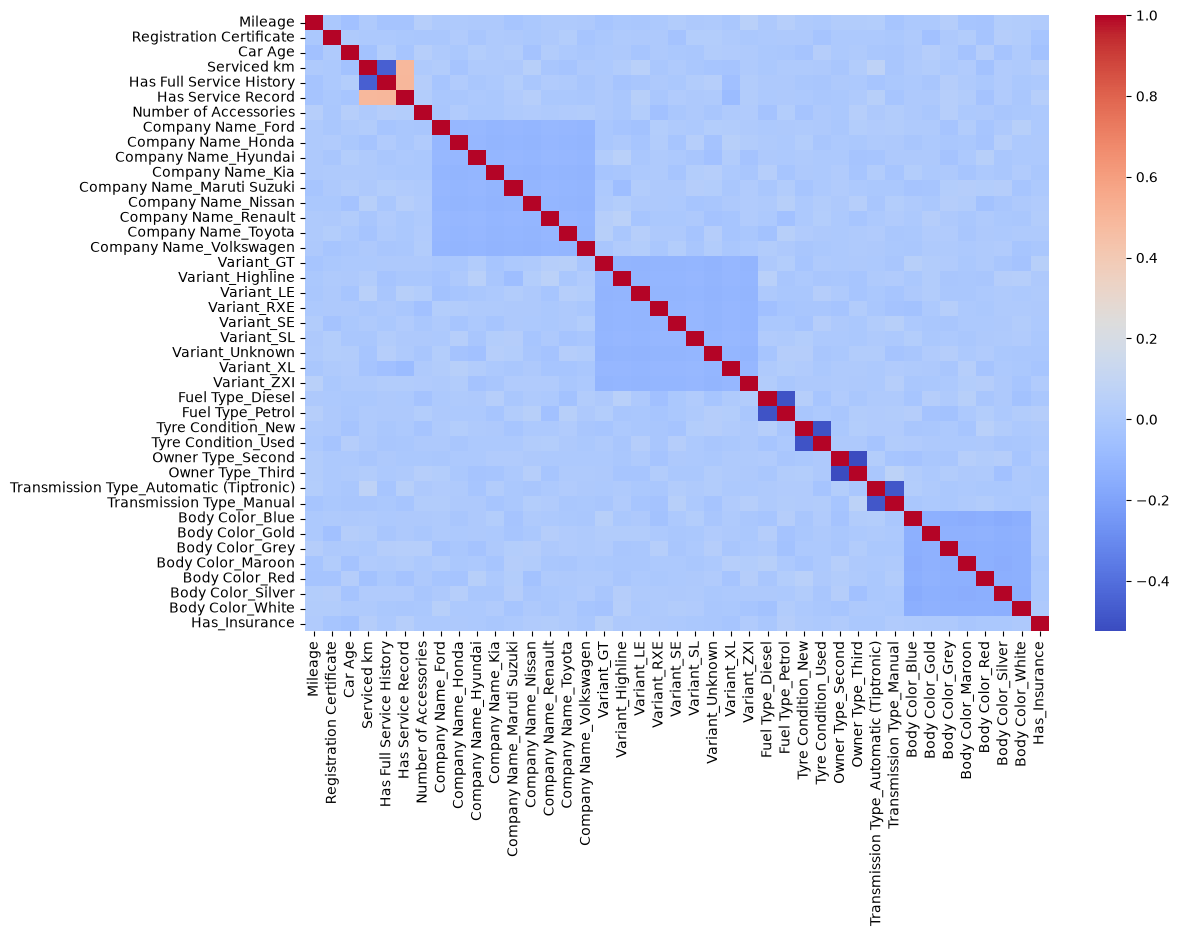

In [545]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

The correlation matrix shows that most features have weak correlations with each other, indicating that there is no major multicollinearity among the predictors. Highly correlated or redundant features, such as Make Year and Car Age, were identified and one was removed. Price per Mile was also excluded from the predictors because it was derived from the target variable, Price, and could cause data leakage. Overall, the remaining features are suitable for proceeding to PCA for dimensionality reduction.

5.2 PCA

The goal is to reduce the current features into fewer components while maintaining most of the information.


In [548]:
# Checking how much variance each principal component explains
pca = PCA()

X_train_pca = pca.fit_transform(X_train_scaled)

In [549]:
# Checking the explained variance
pca.explained_variance_ratio_

array([0.03975665, 0.03937276, 0.03801897, 0.03751985, 0.03703466,
       0.03475445, 0.03136255, 0.03108395, 0.03018896, 0.02968813,
       0.02946806, 0.02942794, 0.02890416, 0.02873233, 0.02827624,
       0.02795954, 0.02770067, 0.0276019 , 0.02691558, 0.02665736,
       0.02603744, 0.02597965, 0.02555327, 0.02525744, 0.02506182,
       0.02459509, 0.02436417, 0.02365956, 0.02345818, 0.0229642 ,
       0.02259002, 0.02205364, 0.02123761, 0.01270242, 0.01214773,
       0.01153143, 0.01082148, 0.00342215, 0.00273655, 0.00251298,
       0.00088848])

In [550]:
# Calculating the cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

cumulative_variance

array([0.03975665, 0.07912941, 0.11714838, 0.15466823, 0.19170289,
       0.22645734, 0.25781989, 0.28890384, 0.3190928 , 0.34878092,
       0.37824898, 0.40767692, 0.43658108, 0.46531341, 0.49358964,
       0.52154919, 0.54924986, 0.57685175, 0.60376733, 0.6304247 ,
       0.65646214, 0.68244179, 0.70799505, 0.73325249, 0.75831431,
       0.7829094 , 0.80727358, 0.83093314, 0.85439132, 0.87735552,
       0.89994554, 0.92199918, 0.94323679, 0.95593921, 0.96808694,
       0.97961837, 0.99043985, 0.993862  , 0.99659855, 0.99911152,
       1.        ])

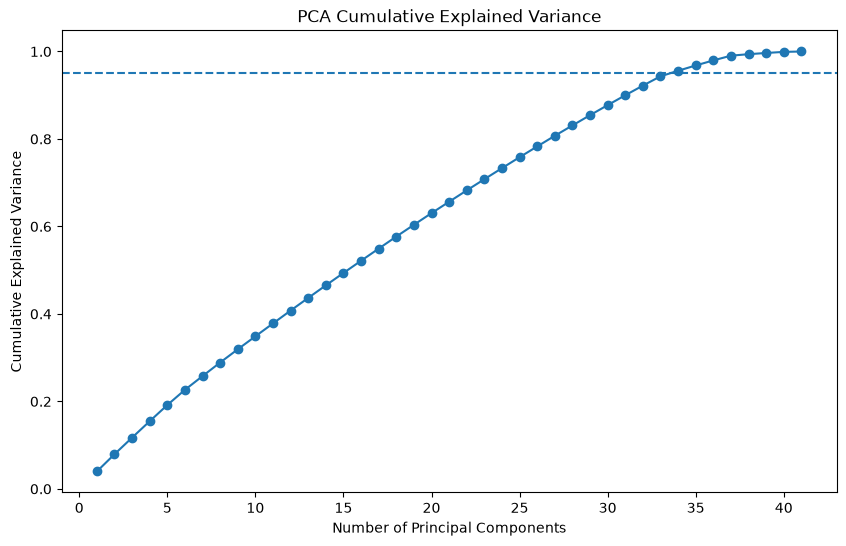

In [551]:
# Plotting the cumulative explained variance
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.axhline(y=0.95, linestyle='--')

plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Cumulative Explained Variance')

plt.show()

In [552]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Number of components for 95% variance:", n_components_95)

Number of components for 95% variance: 34


The minimum number of principal components needed to retain at least 95% of the variance is `34`

In [553]:
# Performing final PCA
pca = PCA(n_components=34)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [554]:
# Confirming the reduction
print("Original training shape:", X_train_scaled.shape)
print("PCA training shape:", X_train_pca.shape)

print("Original test shape:", X_test_scaled.shape)
print("PCA test shape:", X_test_pca.shape)

print("Total variance retained:", pca.explained_variance_ratio_.sum())

Original training shape: (2000, 41)
PCA training shape: (2000, 34)
Original test shape: (500, 41)
PCA test shape: (500, 34)
Total variance retained: 0.9559392057034202


PCA reduced the feature space from 41 features to 34 principal components while retaining approximately 95.59% of the total variance. This reduces the dimensionality of the dataset while preserving most of the information contained in the original features.

**6. Modelling and Evaluation**

6.1 Linear Regression

In [555]:
lr_model = LinearRegression()

lr_model.fit(X_train_pca, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](34,)","[ 7213.83, 6125.07, 4782.19,..., 3387.07,-7645.79,-7649.72]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.102e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(34)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](34,)","[57.1 ,56.82,55.84,...,42.53,41.73,32.27]"


In [556]:
# Making predictions
y_pred_lr = lr_model.predict(X_test_pca)

In [557]:
# Evaluating the model
mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Linear Regression
MAE: 206409.8374732857
RMSE: 237551.7746240547
R²: -0.018288117172730045


In [558]:
# Comparing training vs testing performance
y_train_pred_lr = lr_model.predict(X_train_pca)

train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_pred_lr)

print("Training R²:", train_r2_lr)
print("Testing R²:", test_r2_lr)

Training R²: 0.016228437817842223
Testing R²: -0.018288117172730045


The Linear Regression model performed poorly, with a training R² of 0.016 and a testing R² of -0.018. The negative test R² indicates that the model performed slightly worse than predicting the average car price. The similar low performance on both the training and testing sets suggests underfitting rather than overfitting.

6.2 Random Forest Regressor

In [559]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_pca, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [560]:
# Make predictions
y_pred_rf = rf_model.predict(X_test_pca)

In [561]:
# Evaluating the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regressor")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Regressor
MAE: 212380.02946000002
RMSE: 243102.45069980118
R²: -0.06643107461565823


In [562]:
# Comparing training vs testing set
y_train_pred_rf = rf_model.predict(X_train_pca)

train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_pred_rf)

print("Training R²:", train_r2_rf)
print("Testing R²:", test_r2_rf)

Training R²: 0.8567542455170772
Testing R²: -0.06643107461565823


The Random Forest Regressor achieved a training R² of 0.857 but a testing R² of -0.066, indicating substantial overfitting. It also produced an MAE of 212,380 and an RMSE of 243,102. Although the model captured patterns in the training data, it failed to generalize to unseen data and performed slightly worse than Linear Regression on the test set.

6.3 Gradient Boosting Regressor

In [563]:
# Training the model
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    random_state=42
)

gb_model.fit(X_train_pca, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [564]:
# Making predictions
y_pred_gb = gb_model.predict(X_test_pca)

In [565]:
# Evaluating
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Regressor")
print("MAE:", mae_gb)
print("RMSE:", rmse_gb)
print("R²:", r2_gb)

Gradient Boosting Regressor
MAE: 211453.4975154208
RMSE: 243047.39715921326
R²: -0.06594811643576826


In [566]:
# Training vs Testing
y_train_pred_gb = gb_model.predict(X_train_pca)

train_r2_gb = r2_score(y_train, y_train_pred_gb)
test_r2_gb = r2_score(y_test, y_pred_gb)

print("Training R²:", train_r2_gb)
print("Testing R²:", test_r2_gb)

Training R²: 0.27339908495443677
Testing R²: -0.06594811643576826


The Gradient Boosting Regressor achieved a training R² of 0.273 and a testing R² of -0.066. Its MAE was approximately 211,453 and RMSE was 243,047. Although it captured more variation in the training data than Linear Regression, its negative test R² indicates poor generalization to unseen data.

Comparing models before and after PCA to evaluate whether PCA improved or reduced predictive performance. This is because all models have negativr R2 despite having very different complexity.

1. Linear Regression without PCA

In [567]:
lr_no_pca = LinearRegression()

lr_no_pca.fit(X_train_scaled, y_train)

y_pred_lr_no_pca = lr_no_pca.predict(X_test_scaled)

In [568]:
mae_lr_no_pca = mean_absolute_error(y_test, y_pred_lr_no_pca)
rmse_lr_no_pca = np.sqrt(mean_squared_error(y_test, y_pred_lr_no_pca))
r2_lr_no_pca = r2_score(y_test, y_pred_lr_no_pca)

print("Linear Regression Without PCA")
print("MAE:", mae_lr_no_pca)
print("RMSE:", rmse_lr_no_pca)
print("R²:", r2_lr_no_pca)

Linear Regression Without PCA
MAE: 206363.79560503192
RMSE: 237622.62889280348
R²: -0.018895654793409378


In [569]:
y_train_pred_lr_no_pca = lr_no_pca.predict(X_train_scaled)

train_r2_lr_no_pca = r2_score(y_train, y_train_pred_lr_no_pca)
test_r2_lr_no_pca = r2_score(y_test, y_pred_lr_no_pca)

print("Training R²:", train_r2_lr_no_pca)
print("Testing R²:", test_r2_lr_no_pca)

Training R²: 0.019944512290860916
Testing R²: -0.018895654793409378


Linear Regression was evaluated both before and after PCA. Without PCA, the model achieved a test R² of -0.0189, while after PCA the test R² was -0.0183. The MAE and RMSE were also very similar. Therefore, reducing the feature space from 41 features to 34 principal components while retaining approximately 95.59% of the variance did not substantially change model performance. This indicates that PCA reduced dimensionality while preserving most of the predictive information available in the original feature set.

In [570]:
model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Training R²': [
        train_r2_lr,
        train_r2_rf,
        train_r2_gb
    ],
    'Testing R²': [
        test_r2_lr,
        test_r2_rf,
        test_r2_gb
    ],
    'MAE': [
        mae_lr,
        mae_rf,
        mae_gb
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf,
        rmse_gb
    ]
})

model_comparison

,Model,Training R²,Testing R²,MAE,RMSE
0,Linear Regression,0.016228,-0.018288,206409.837473,237551.774624
1,Random Forest,0.856754,-0.066431,212380.029460,243102.450700
2,Gradient Boosting,0.273399,-0.065948,211453.497515,243047.397159


Three regression models were evaluated using the PCA-transformed dataset. Linear Regression produced a test R² of -0.018, Random Forest -0.066, and Gradient Boosting -0.066. All models produced negative test R² values, indicating poor predictive performance on unseen data. Random Forest showed substantial overfitting, with a training R² of 0.857 compared with a testing R² of -0.066. Linear Regression showed the strongest test-set metrics among the evaluated models, although its predictive performance remained weak. Further feature engineering, additional predictive variables, and model optimization may be necessary to improve price prediction.

**7. Conclusion**

This project applied feature engineering and dimensionality reduction techniques to prepare second-hand car data for machine learning. New features such as Car Age, Price per Mile, Number of Accessories, service history and insurance indicators were created to extract useful information from the original variables. Categorical variables were encoded, numerical features were standardized, and correlation analysis was used to identify redundant features.

PCA was then applied to reduce the feature space from 41 features to 34 principal components while retaining approximately 95.59% of the total variance. Comparing Linear Regression before and after PCA showed very similar performance, indicating that PCA successfully reduced dimensionality without substantially changing the predictive information available to the model.

Three regression models were evaluated on the PCA-transformed data: Linear Regression, Random Forest Regressor, and Gradient Boosting Regressor. All three produced negative test R² values, indicating weak generalization to unseen data. Random Forest showed substantial overfitting, achieving a training R² of approximately 0.857 but a testing R² of -0.066. Gradient Boosting achieved a training R² of 0.273 and testing R² of -0.066. Linear Regression produced a testing R² of approximately -0.018 and the lowest RMSE among the three models, although its overall predictive performance remained weak.

Overall, the project demonstrates that dimensionality reduction can simplify the feature space while preserving most of its information, but dimensionality reduction alone does not guarantee improved predictive accuracy.


**Future Improvements** 

Future improvements could include collecting additional variables that may better explain second-hand car prices, such as specific car model, engine capacity, vehicle condition, accident history, location, and market demand. Further feature engineering could also investigate interactions between existing variables. Hyperparameter tuning and additional regression algorithms could be explored to improve generalization. Finally, different PCA variance thresholds or alternative dimensionality-reduction and feature-selection techniques could be compared to determine whether a smaller and more predictive feature set can be obtained.